Importing the Dependencies

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection and Processing

In [43]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv('/content/car.csv')

In [44]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [45]:
# checking the number of rows and columns
car_dataset.shape

(301, 9)

In [46]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [47]:
import datetime

current_year = datetime.datetime.now().year
car_dataset['Car_Age'] = current_year - car_dataset['Year']
car_dataset.drop('Year', axis=1, inplace=True)

In [48]:
# checking the number of missing values
car_dataset.isnull().sum()

,0
Car_Name,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0
Car_Age,0


In [49]:
# checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding the Categorical Data

In [50]:
# encoding "Fuel_Type" Column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

# encoding "Seller_Type" Column
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)

# encoding "Transmission" Column
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_3681/336345893.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_3681/336345893.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_3681/336345893.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=Fal

In [51]:
car_dataset.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,0,0,0,0,12
1,sx4,4.75,9.54,43000,1,0,0,0,13
2,ciaz,7.25,9.85,6900,0,0,0,0,9
3,wagon r,2.85,4.15,5200,0,0,0,0,15
4,swift,4.60,6.87,42450,1,0,0,0,12


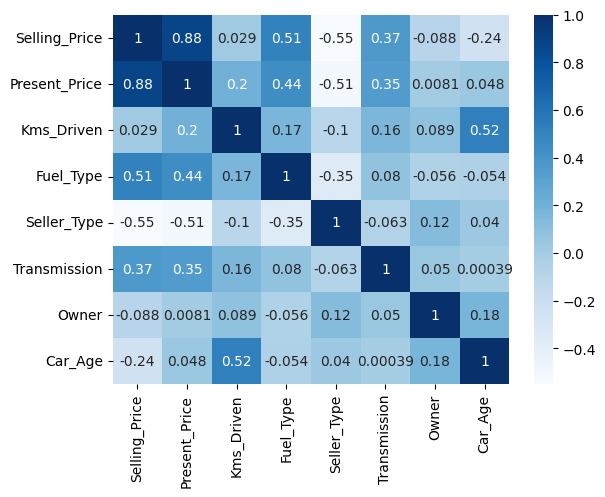

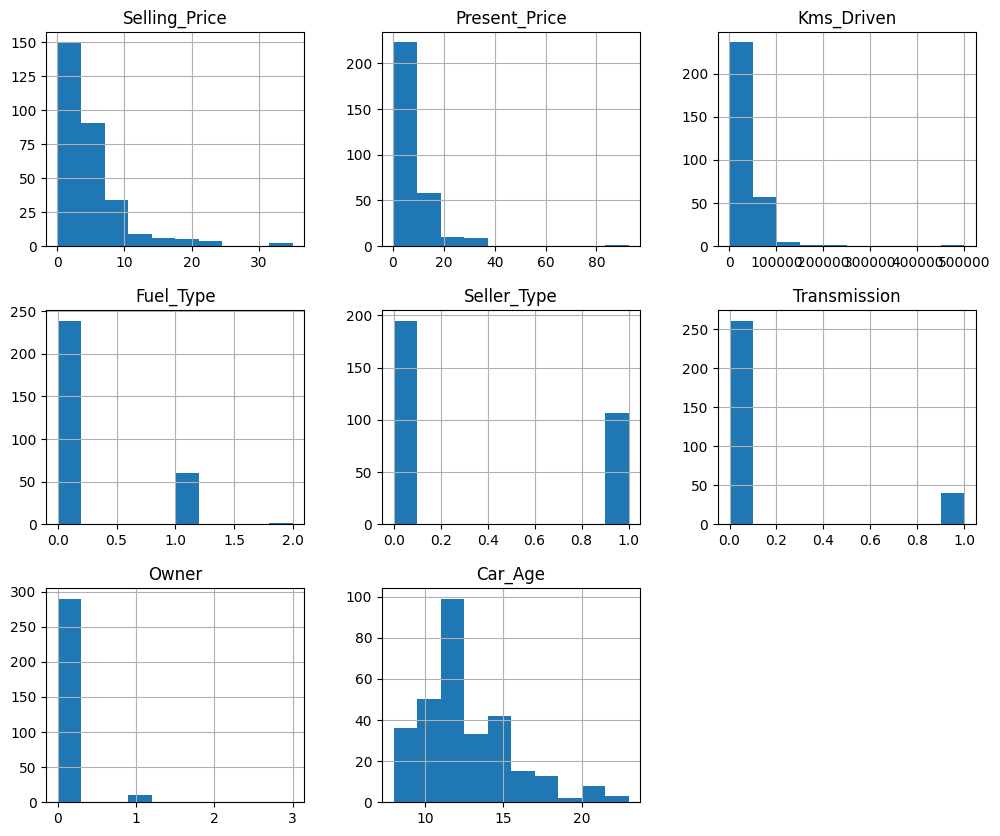

In [75]:
car_dataset.drop('Car_Name', axis=1, inplace=True)
sns.heatmap(car_dataset.corr(), annot=True, cmap='Blues')
plt.show()

car_dataset.hist(figsize=(12,10))
plt.show()

Splitting the data and Target

In [52]:
X = car_dataset.drop(['Car_Name','Selling_Price'],axis=1)
Y = car_dataset['Selling_Price']

In [53]:
print(X)

     Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  Owner  \
0             5.59       27000          0            0             0      0   
1             9.54       43000          1            0             0      0   
2             9.85        6900          0            0             0      0   
3             4.15        5200          0            0             0      0   
4             6.87       42450          1            0             0      0   
..             ...         ...        ...          ...           ...    ...   
296          11.60       33988          1            0             0      0   
297           5.90       60000          0            0             0      0   
298          11.00       87934          0            0             0      0   
299          12.50        9000          1            0             0      0   
300           5.90        5464          0            0             0      0   

     Car_Age  
0         12  
1         13  
2     

In [54]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


Splitting Training and Test data

In [55]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=2)

Model Training

1. Linear Regression

In [56]:
# loading the linear regression model
lin_reg_model = LinearRegression()

In [57]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [58]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [59]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8799451660493707


Visualize the actual prices and Predicted prices

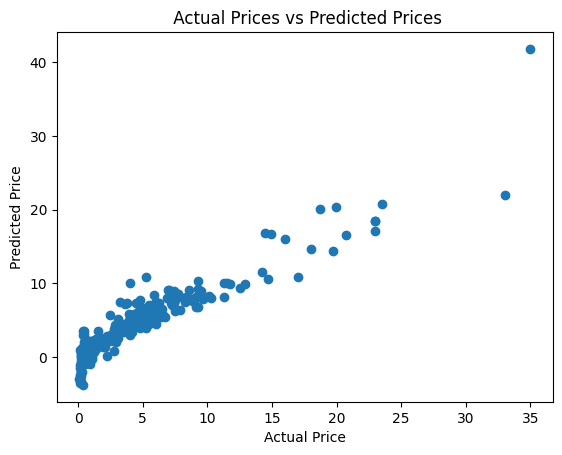

In [60]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [61]:
# prediction on Training data
test_data_prediction = lin_reg_model.predict(X_test)

In [62]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8365766715024979


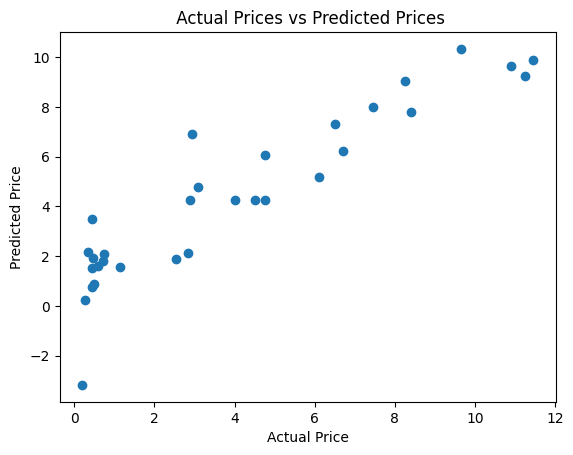

In [63]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

2. Lasso Regression

In [64]:
# loading the linear regression model
lass_reg_model = Lasso()

In [65]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

Model Evaluation

In [66]:
# prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train)

In [67]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8427865861257862


Visualize the actual prices and Predicted prices

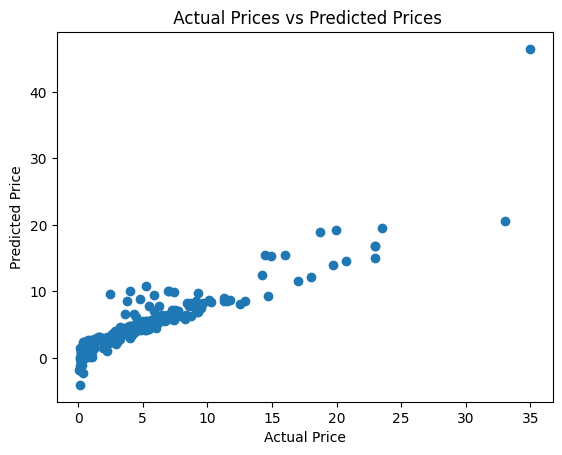

In [68]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

In [69]:
# R squared Error
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(Y_train, training_data_prediction)
rmse = np.sqrt(mse)
print("Mean squared Error : ", mse)
print("R squared Error : ", rmse)

Mean squared Error :  4.267744536337575
R squared Error :  2.065852012206483


In [70]:
# prediction on Testing data
test_data_prediction = lass_reg_model.predict(X_test)

In [71]:
# R squared Error
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(Y_test, test_data_prediction)
rmse = np.sqrt(mse)
print("Mean squared Error : ", mse)
print("R squared Error : ", rmse)

Mean squared Error :  1.6983451309316817
R squared Error :  1.3032057132055865


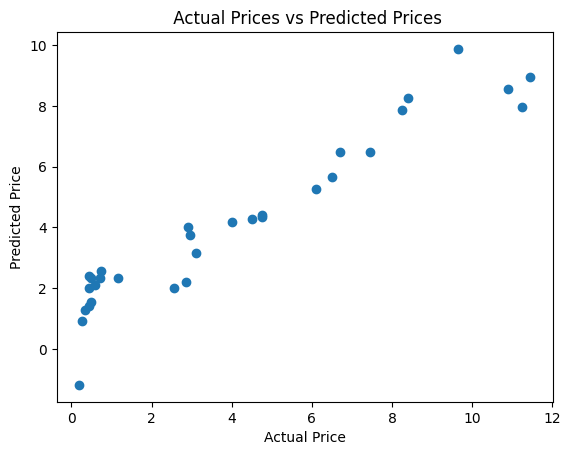

In [72]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(" Actual Prices vs Predicted Prices")
plt.show()

Random Forest Regressor

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [76]:
rf_prediction = rf_model.predict(X_test)

print("R2:", metrics.r2_score(Y_test, rf_prediction))

mse = metrics.mean_squared_error(Y_test, rf_prediction)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.9831928484027589
MSE: 0.2211285245161298
RMSE: 0.4702430483442895


Hyperparameter Tuning

In [77]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    n_iter=10,
    cv=5,
    random_state=42
)

search.fit(X_train,Y_train)

print(search.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
